## Introduction to NetworkX

![](img/NetworkX.jpg)

This notebook is based on: https://github.com/rossanoventurini/adsds/blob/main/Lab/Lecture_08/L08_Graphs_with_NetworkX_no_sols.ipynb

---

### Get prepared

#### Required installations

tbd

#### Imports

In [1]:
import networkx as nx
import pandas as pd
pd.options.display.max_rows = 400
import matplotlib.pyplot as plt

#### Some functions

In [2]:
def plot_graph(G, size=5):
    plt.figure(figsize=(size, size))
    nx.draw(G, with_labels=True, node_color='skyblue', width=.3, font_size=8)
    plt.show()

def plot_graph_with_weights(G):
    pos = nx.planar_layout(G) # pos = nx.nx_agraph.graphviz_layout(G)
    nx.draw_networkx(G,pos)
    labels = nx.get_edge_attributes(G,'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
    plt.show()

---

### Basic graph construction

#### Create an empty graph

In [4]:
G = nx.Graph()
type(G)

networkx.classes.graph.Graph

#### Populate the graph


 We can add one node at time using the `add_node` method or add any iterable collections (lists, strings etc..) with the `G.add_nodes_from` method. 

We are now using strings as node names, but node names can be any hashable object.

In [5]:
G.add_node('a')
my_list = ['b', 'c', 'd']
G.add_nodes_from(my_list)

We can add one edge at time with `G.add_edge()`, specifying the nodes between which we want the edge to stay. As for nodes, we can pass an iterable colletion to `G.add_edges_from()`.

In [6]:
G.add_edges_from([('a', 'b'), ('a', 'c'), ('c', 'd'), ('b', 'd')])
G.edges()
list(G.edges())

[('a', 'b'), ('a', 'c'), ('b', 'd'), ('c', 'd')]

If we add edges between nodes that do not exist, theses nodes are automatically added.

In [7]:
G.add_edge("a", "e")
G.add_edge("a", "f")
G.add_edge("a", "b")
list(G.nodes())

['a', 'b', 'c', 'd', 'e', 'f']

#### Inspect the graph

We can inspect the nodes in a graph using `G.nodes()`.

In [8]:
G.nodes()
list(G.nodes())

['a', 'b', 'c', 'd', 'e', 'f']

We can inspect the edges in a graph using `G.edges()`.

In [9]:
G.edges()
list(G.edges())

[('a', 'b'), ('a', 'c'), ('a', 'e'), ('a', 'f'), ('b', 'd'), ('c', 'd')]

An initial graph visualization

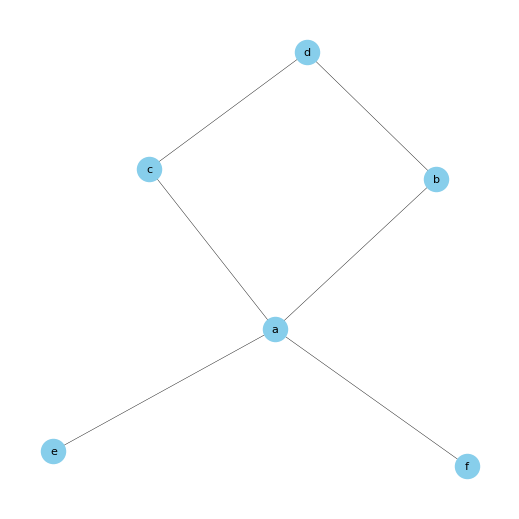

In [10]:
plot_graph(G)

In [11]:
# Number of nodes
print("Number of Nodes: ", G.number_of_nodes()) # equivalent to len(G) and G.order()
# Number of edges
print("Number of Edges: ", G.number_of_edges())

Number of Nodes:  6
Number of Edges:  6


Second graph visualization.

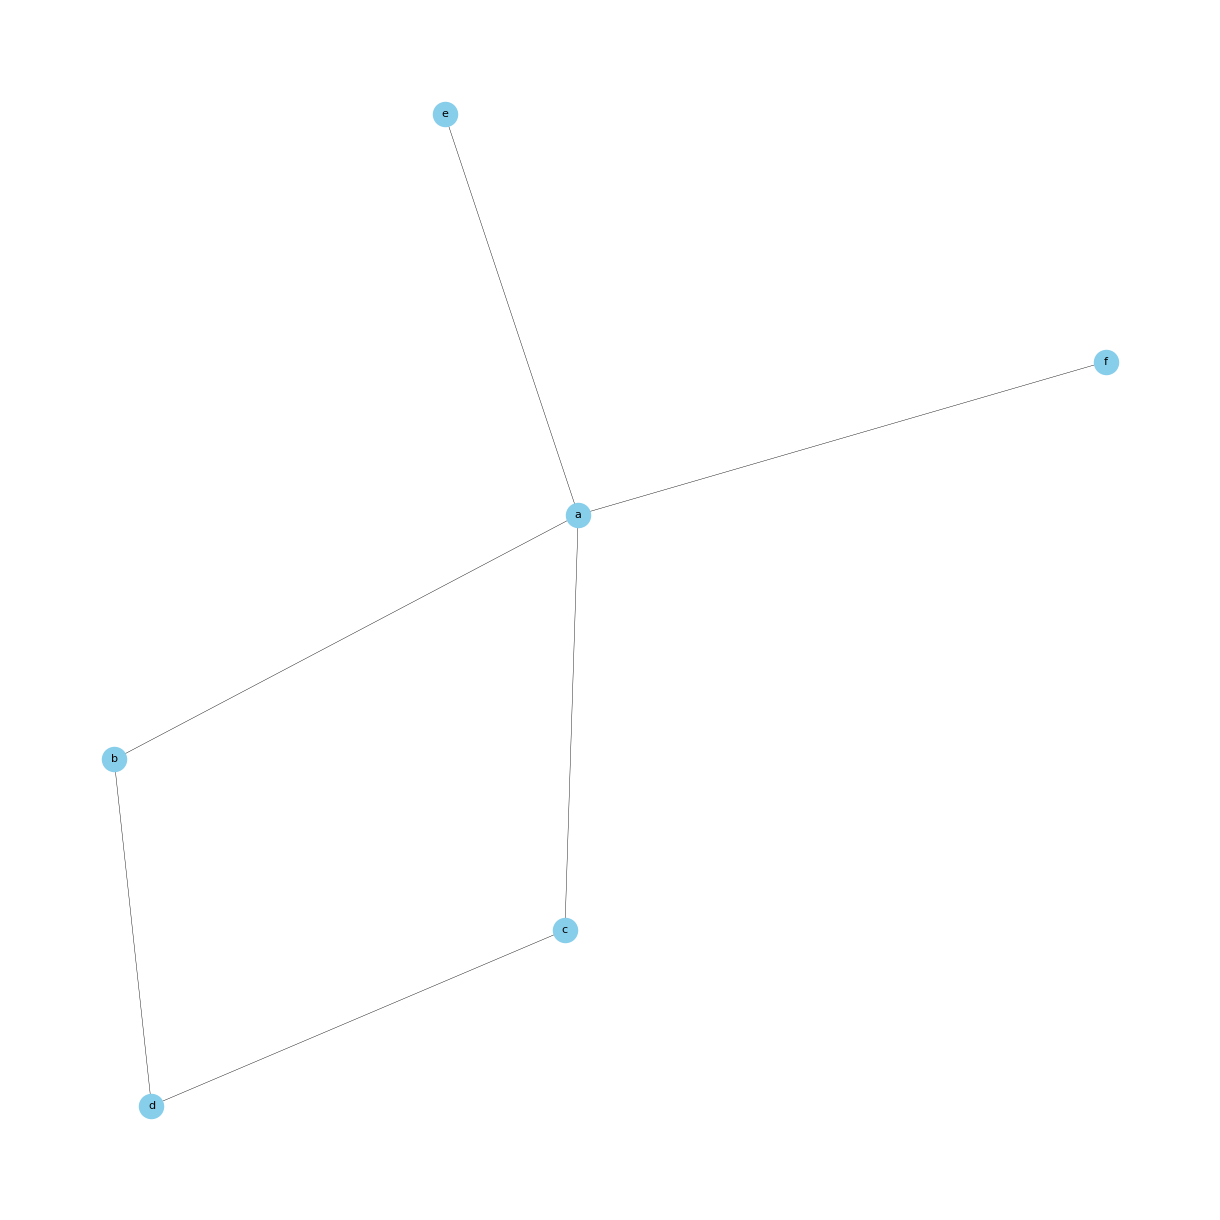

In [12]:
plot_graph(G, 12)

Remove nodes using the `G.remove_node()` or the `G.remove_nodes_from()`

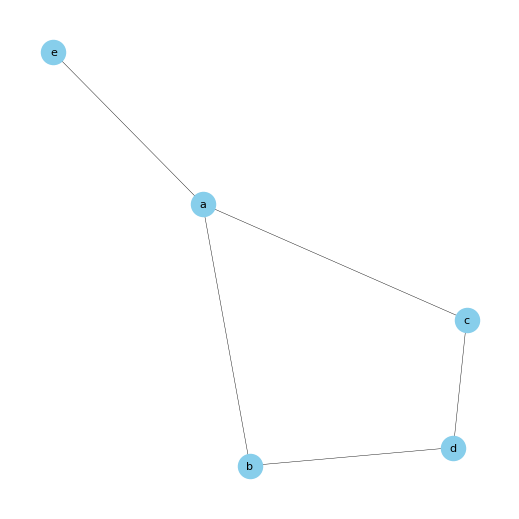

In [23]:
G.remove_node('f')
plot_graph(G)

Let's now query for the nodeset. See the first 5 nodes.
(We use the `list()` constructor to refer to the Python basic types.)

In [24]:
list(G.nodes())[0:10]

['a', 'b', 'c', 'd', 'e']

Because a `G.nodes()` is iterable, 
we can query it for its length:

In [25]:
len(G.nodes())

5

Query for the edgeset.

In [26]:
list(G.edges())[0:5]

[('a', 'b'), ('a', 'c'), ('a', 'e'), ('b', 'd'), ('c', 'd')]

---

### Add attributes

In advance: 
In Python, a node is a tuple of the form `(n, node_attribute_dict)`. 
Similar are edges: `(n1, n2, edge_attribute_dict)`

Add attributes to nodes

In [27]:
for node in G.nodes:
    G.nodes[node]['color'] = 'white'

Query for the nodeset including attributes.

In [28]:
list(G.nodes(data=True))

[('a', {'color': 'white', 'degree': 4}),
 ('b', {'color': 'white', 'degree': 2}),
 ('c', {'color': 'white', 'degree': 2}),
 ('d', {'color': 'white', 'degree': 2}),
 ('e', {'color': 'white', 'degree': 1})]

In [18]:
G.nodes['a']['color']

'white'

Additionally, we can set the attributes of individual nodes:

In [29]:
G.nodes["c"]['color'] = 'green'
G.nodes["d"]['color'] = 'yellow'
list(G.nodes(data=True))

[('a', {'color': 'white', 'degree': 4}),
 ('b', {'color': 'white', 'degree': 2}),
 ('c', {'color': 'green', 'degree': 2}),
 ('d', {'color': 'yellow', 'degree': 2}),
 ('e', {'color': 'white', 'degree': 1})]

Add attributes to edges

In [30]:
G['a']['b']['color'] = 'green'
G['a']['c']['color'] = 'black'
list(G.edges(data=True))

[('a', 'b', {'color': 'green', 'weight': 1}),
 ('a', 'c', {'color': 'black', 'weight': 2}),
 ('a', 'e', {'weight': 3}),
 ('b', 'd', {'weight': 5}),
 ('c', 'd', {'weight': 6})]

Now, we add `weight` attributes to the edges.

In [31]:
w = 1
for u, v, data in G.edges(data=True):
    data['weight'] = w
    w += 1
list(G.edges(data=True))

[('a', 'b', {'color': 'green', 'weight': 1}),
 ('a', 'c', {'color': 'black', 'weight': 2}),
 ('a', 'e', {'weight': 3}),
 ('b', 'd', {'weight': 4}),
 ('c', 'd', {'weight': 5})]

---

### Some calculations with graph measures

#### Calculate node degree

Make the degree values a `dict`ionary, then add it as nodes' attributes with `networkx.set_node_attributes()`

In [32]:
degrees = dict(nx.degree(G))
nx.set_node_attributes(G, name='degree', values=degrees)
dict(G.nodes(data='degree'))

{'a': 3, 'b': 2, 'c': 2, 'd': 2, 'e': 1}

Make a Pandas dataframe from the degree data `G.nodes(data='degree')`, then sort from highest to lowest

In [33]:
degree_df = pd.DataFrame(G.nodes(data='degree'), columns=['node', 'degree'])
degree_df = degree_df.sort_values(by='degree', ascending=False)
degree_df

,node,degree
0,a,3
1,b,2
2,c,2
3,d,2
4,e,1


Plot the nodes with the highest degree values

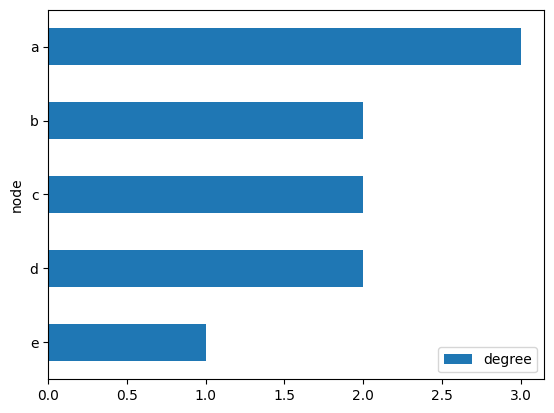

In [34]:
num_nodes_to_inspect = 10
degree_df[:num_nodes_to_inspect].plot(x='node', y='degree', kind='barh').invert_yaxis()

Who has the most number of connections in the network?

To get the key with the maximum value in a dictionary, we pass the dictionary to the max() function as an iterable and use the key parameter to specify the key function, which returns the value to be used for the comparison.

In [37]:
deg = dict(nx.degree(G))
max_key = max(deg, key=deg.get)
max_key

'a'

Now, we can write things like:

In [38]:
for n, attr in list(G.nodes(data=True))[0:5]:
    # n is the node
    # attr is the attributes dictionary
    print(f"{n} {attr}")

a {'color': 'white', 'degree': 3}
b {'color': 'white', 'degree': 2}
c {'color': 'green', 'degree': 2}
d {'color': 'yellow', 'degree': 2}
e {'color': 'white', 'degree': 1}


#### Calculate Weighted Degree

The weighted node degree is the sum of the edge weights for edges incident to that node.

To find out who has the most number of connections in the network, you have to factor in edge weight. To do that, you give the name of the node attribute that holds the weight value. 

In [39]:
list(nx.degree(G, weight='weight'))

[('a', 6), ('b', 5), ('c', 7), ('d', 9), ('e', 3)]

Check by looking at the graph plot.

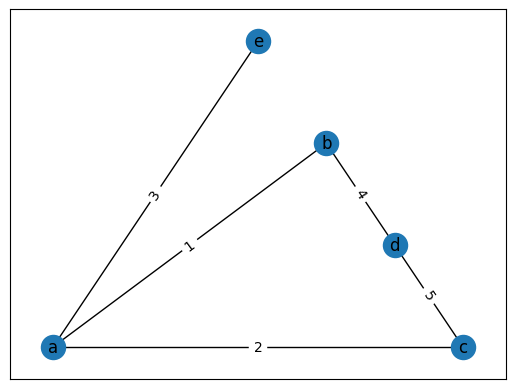

In [41]:
plot_graph_with_weights(G)

Make the weighted degree values a `dict`ionary, then add it as a node attribute with `networkx.set_node_attributes()`

In [40]:
weighted_degrees = dict(nx.degree(G, weight='weight'))
nx.set_node_attributes(G, name='weighted_degree', values=weighted_degrees)
dict(G.nodes(data='weighted_degree'))

{'a': 6, 'b': 5, 'c': 7, 'd': 9, 'e': 3}

Make a Pandas dataframe from the degree data `G.nodes(data='weighted_degree')`, then sort from highest to lowest

In [42]:
weighted_degree_df = pd.DataFrame(G.nodes(data='weighted_degree'), columns=['node', 'weighted_degree'])
weighted_degree_df = weighted_degree_df.sort_values(by='weighted_degree', ascending=False)
weighted_degree_df

,node,weighted_degree
3,d,9
2,c,7
0,a,6
1,b,5
4,e,3


Plot bar chart for weighted degree values.

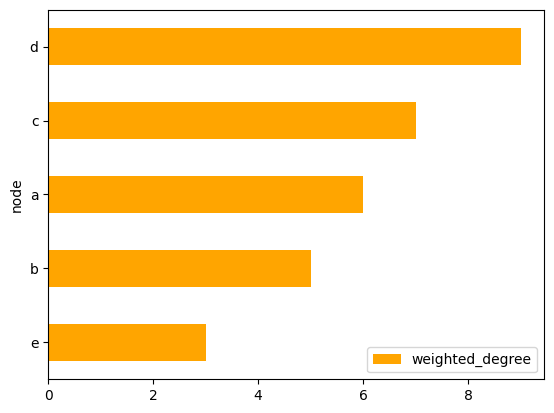

In [44]:
num_nodes_to_inspect = 10
weighted_degree_df[:num_nodes_to_inspect].plot(x='node', y='weighted_degree', color='orange', kind='barh').invert_yaxis()

#### Calculate Betweenness Centrality Scores

In graph theory, betweenness centrality is a measure of centrality in a graph based on shortest paths. 
In short: How many shortest paths pass a node?
More precise: What is the fraction of a graph's shortest paths that pass a certain node?

In [ ]:
nx.betweenness_centrality(G)

In [46]:
betweenness_centrality = nx.betweenness_centrality(G)

Add `betweenness_centrality` (which is already a dictionary) as a node attribute with `networkx.set_node_attributes()`

In [47]:
nx.set_node_attributes(G, name='betweenness', values=betweenness_centrality)

Make a Pandas dataframe from the betweenness data `G.nodes(data='betweenness')`, then sort from highest to lowest

In [48]:
betweenness_df = pd.DataFrame(G.nodes(data='betweenness'), columns=['node', 'betweenness'])
betweenness_df = betweenness_df.sort_values(by='betweenness', ascending=False)
betweenness_df

,node,betweenness
0,a,0.583333
1,b,0.166667
2,c,0.166667
3,d,0.083333
4,e,0.000000


Plot the nodes with the highest betweenness centrality scores

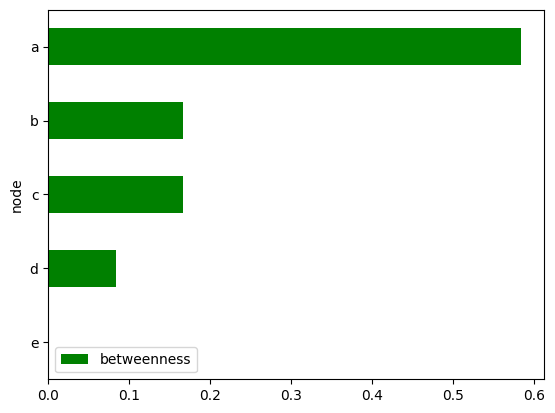

In [49]:
num_nodes_to_inspect = 10
betweenness_df[:num_nodes_to_inspect].plot(x='node', y='betweenness', color='green', kind='barh').invert_yaxis()

---

### Graph Operations

Networkx supports most common graph operations. Some examples are 
<ul>
<li>Union</li>
<li>Intersection</li>
<li>Complement</li>
</ul>

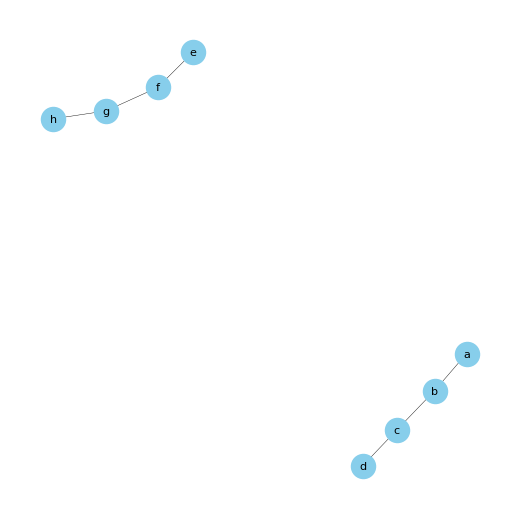

In [50]:
# Create a first graph G
G = nx.Graph()
G.add_edges_from([("a", "b"), ("b", "c"), ("c", "d")])

# Create a second graph H
H = nx.Graph()
H.add_edges_from([("e", "f"), ("f", "g"), ("g", "h") ])

# Perform the union operation
I = nx.union(G, H)
plot_graph(I)

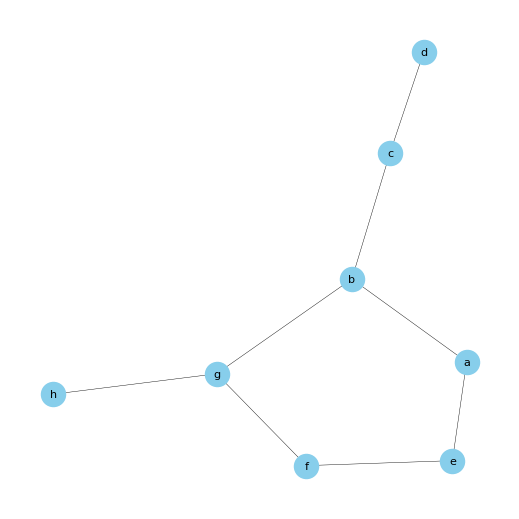

In [51]:
# Now link the two connected components
I.add_edges_from([("a","e"), ("b", "g")])
plot_graph(I)

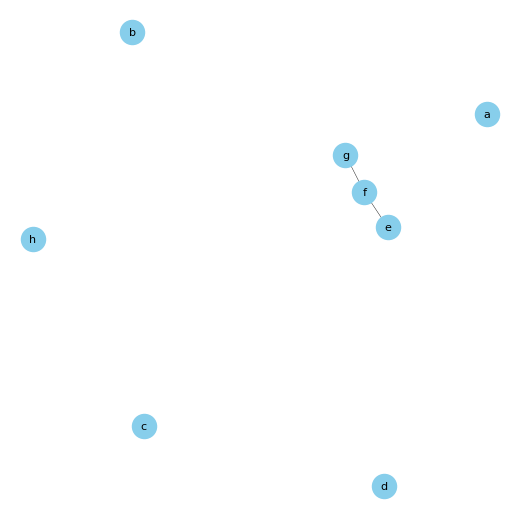

In [52]:
# Create a third graph
L = nx.Graph()

# To perform intersection between two graphs, they must have the same nodes
# First we copy all the nodes in I into L
L.add_nodes_from(I.nodes())

# Then we add some edge in L
L.add_edges_from([("e", "f"), ("f", "g")])

M = nx.intersection(I, L)

# Only the shared edges between I, L wil survive this operation
plot_graph(M)